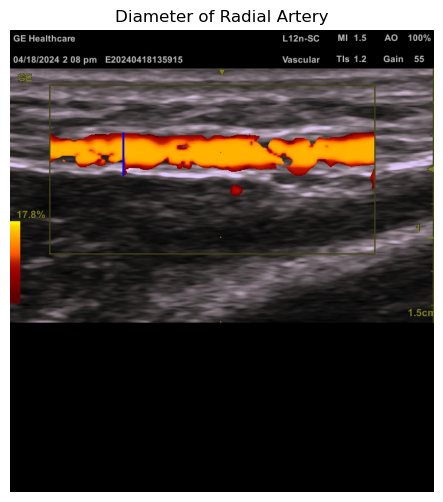

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the color Doppler image
img = cv2.imread("C:\\Users\\amaew\\OneDrive\\Documents\\Biom300_Prob4_Pictures\\AbbyMae_zone2\\1713449313.JPG")

# Convert to HSV for better color segmentation
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Define red/orange HSV ranges for Doppler blood flow colors
lower_red1 = np.array([0, 70, 50])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([160, 70, 50])
upper_red2 = np.array([180, 255, 255])

lower_orange = np.array([10, 100, 100])
upper_orange = np.array([25, 255, 255])

# Combine masks for red and orange
mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
mask3 = cv2.inRange(hsv, lower_orange, upper_orange)
doppler_mask = cv2.bitwise_or(mask1, mask2)
doppler_mask = cv2.bitwise_or(doppler_mask, mask3)

# Find contours in the Doppler mask
contours, _ = cv2.findContours(doppler_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
doppler_contour = max(contours, key=cv2.contourArea)

# Draw filled Doppler mask for pixel-level checks
filled_mask = np.zeros_like(doppler_mask)
cv2.drawContours(filled_mask, [doppler_contour], -1, 255, -1)

# Prepare overlay
overlay = img.copy()

# Scan columns inside the red Doppler area to find vertical spans
height, width = filled_mask.shape
min_diameter = None
min_points = None

for x in range(width):
    column = filled_mask[:, x]
    white_pixels = np.where(column == 255)[0]

    if len(white_pixels) >= 2:
        top = white_pixels[0]
        bottom = white_pixels[-1]
        diameter = bottom - top

        if min_diameter is None or diameter > min_diameter:
            min_diameter = diameter
            min_points = (x, top, bottom)

# Draw best-fit blue diameter line from red to red
if min_points:
    x, y1, y2 = min_points
    cv2.line(overlay, (x, y1), (x, y2), (255, 0, 0), 2)  

# Display result
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Diameter of Radial Artery")
plt.axis('off')
plt.savefig('Diameter_of_Radial_Artery.png')
plt.show()